# CTR Prediction for Avazu — Online Learning

**Objective:** Predict the probability that a mobile ad impression results in a click, using two models trained via online learning on ~40 million observations.

**Models:** Logistic Regression (SGD) and Naïve Bayes  
**Metric:** Log Loss  
**Approach:** Chunked processing with `partial_fit()` — the dataset never fully loads into memory.

---

## Section 0 — Setup & Configuration

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction import FeatureHasher
from tqdm import tqdm

# ── Constants (change these in one place) ────────────────────────────────────
DATA_PATH = "../data/train.gz"
CHUNK_SIZE = 50_000        # rows per mini-batch
N_FEATURES = 2**18         # hash buckets (262,144)
TRAIN_RATIO = 0.8          # first 80 % of rows for training

---

## Section 1 — Exploratory Data Analysis

**Goal:** Understand the dataset before modelling. We draw a random sample of ~100,000 rows spread across all 10 days, so our exploration reflects the full dataset — not just the first hour.

Key questions:
- How many columns? What do they represent?
- How imbalanced is the target variable (click)?
- How many unique values does each column have? (This drives feature selection.)
- Are there time-of-day patterns in click behaviour?

In [3]:
# Load a RANDOM sample for exploration
# Instead of the first 100K rows (which all fall in the same hour),
# we sample ~0.25% of rows from each chunk → ~100K rows spread across all 10 days.
SAMPLE_RATE = 0.0025

sample_chunks = []
reader = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE)
for chunk in reader:
    sampled = chunk.sample(frac=SAMPLE_RATE, random_state=42)
    if len(sampled) > 0:
        sample_chunks.append(sampled)

sample = pd.concat(sample_chunks, ignore_index=True)
del sample_chunks  # free memory

print(f"Random sample shape: {sample.shape}")
print(f"\nColumn types:\n{sample.dtypes}")
sample.head()


Random sample shape: (101072, 24)

Column types:
id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id                 str
site_domain             str
site_category           str
app_id                  str
app_domain              str
app_category            str
device_id               str
device_ip               str
device_model            str
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
dtype: object


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.466295e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15702,320,50,1722,0,35,-1,79
1,1.131323e+19,0,14102100,1005,0,6256f5b4,28f93029,f028772b,ecad2386,7801e8d9,...,1,0,20634,320,50,2374,3,39,100117,23
2,1.002933e+19,1,14102100,1005,1,22d080df,6eb534a7,3e814130,ecad2386,7801e8d9,...,1,2,20596,320,50,2161,0,35,-1,157
3,1.171219e+19,1,14102100,1005,0,803ffc86,8ab8ad36,f028772b,ecad2386,7801e8d9,...,1,2,20596,320,50,2161,0,35,100131,157
4,1.547455e+19,0,14102100,1005,0,4bf5bbe2,6b560cc1,28905ebd,ecad2386,7801e8d9,...,1,0,19665,320,50,2253,2,303,-1,52


In [ ]:
# Cardinality check (exact up to a cap per column) in the whole dataset

MAX_EXACT_UNIQUES = 300_000  # increase if you want more exact counts (uses more RAM)

# Read column names without loading data
all_cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

# Per-column trackers
unique_sets = {c: set() for c in all_cols}
capped_cols = {c: False for c in all_cols}

reader = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, dtype=str)

for chunk in tqdm(reader, desc="Counting unique values (streaming)"):
    for c in all_cols:
        if capped_cols[c]:
            continue

        unique_sets[c].update(chunk[c].dropna().unique())

        if len(unique_sets[c]) > MAX_EXACT_UNIQUES:
            # Stop tracking this column exactly to protect memory
            capped_cols[c] = True
            unique_sets[c] = None

# Build result table
rows = []
for c in all_cols:
    if capped_cols[c]:
        rows.append((c, f">{MAX_EXACT_UNIQUES:,} (high-cardinality)"))
    else:
        rows.append((c, len(unique_sets[c])))

unique_summary = pd.DataFrame(rows, columns=["column", "unique_values"])
print(unique_summary.to_string(index=False))

Counting unique values (streaming): 0it [00:00, ?it/s]

Counting unique values (streaming): 809it [01:11, 11.29it/s]

          column               unique_values
              id >300,000 (high-cardinality)
           click                           2
            hour                         240
              C1                           7
      banner_pos                           7
         site_id                        4737
     site_domain                        7745
   site_category                          26
          app_id                        8552
      app_domain                         559
    app_category                          36
       device_id >300,000 (high-cardinality)
       device_ip >300,000 (high-cardinality)
    device_model                        8251
     device_type                           5
device_conn_type                           4
             C14                        2626
             C15                           8
             C16                           9
             C17                         435
             C18                           4
          

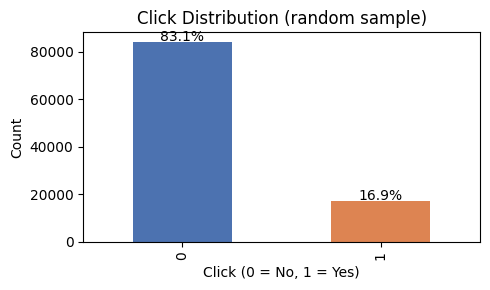

In [ ]:
# ── Class imbalance in the sample ──────────────────────────────────────────────────────────
click_counts = sample["click"].value_counts()
click_pct = sample["click"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 3))
click_counts.plot.bar(ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Click Distribution (random sample)")
ax.set_xlabel("Click (0 = No, 1 = Yes)")
ax.set_ylabel("Count")
for i, (cnt, pct) in enumerate(zip(click_counts, click_pct)):
    ax.text(i, cnt + 500, f"{pct:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cardinality per column in the sample ────────────────────────────────────────────────────
# High-cardinality columns are harder to encode and may not generalize well.
cardinality = sample.nunique().sort_values(ascending=False)
print("Unique values per column:\n")
print(cardinality.to_string())

Unique values per column:

id                  101072
device_ip            78583
device_id            17111
device_model          3134
C14                   1701
site_id               1492
site_domain           1325
app_id                1320
C17                    399
hour                   240
C20                    157
app_domain              94
C19                     63
C21                     60
app_category            23
site_category           20
C16                      9
C15                      8
C1                       7
banner_pos               7
device_type              4
device_conn_type         4
C18                      4
click                    2


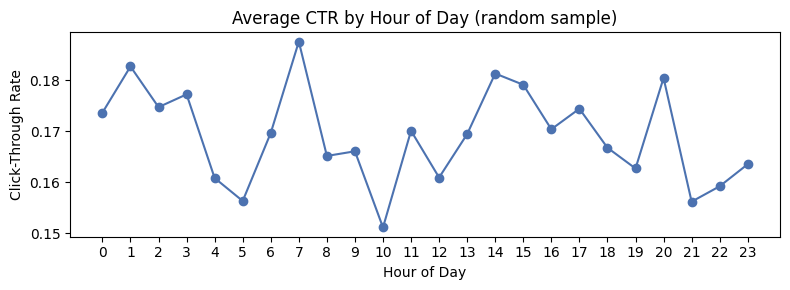

In [13]:
# ── CTR by hour of day ────────────────────────────────────────────────────────
# The 'hour' column is in YYMMDDHH format (e.g. 14102100).
# We extract the last two digits to get the hour of day (0-23).
sample["hour_of_day"] = sample["hour"] % 100

ctr_by_hour = sample.groupby("hour_of_day")["click"].mean()

fig, ax = plt.subplots(figsize=(8, 3))
ctr_by_hour.plot(ax=ax, marker="o", color="#4c72b0")
ax.set_title("Average CTR by Hour of Day (random sample)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Click-Through Rate")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

---

## Section 2 — Feature Selection

Based on the EDA above, here are our inclusion/exclusion decisions:

| Column | Decision | Reason |
|--------|----------|--------|
| `id` | **Drop** | Unique identifier, not a feature |
| `click` | **Target** | This is what we predict |
| `hour` | **Transform** | Extract `hour_of_day` (last 2 digits) — captures daily patterns |
| `C1` | Keep | Low-to-medium cardinality categorical |
| `banner_pos` | Keep | Ad position — likely influences CTR |
| `site_id` | Keep | Identifies the website/placement |
| `site_domain` | Keep | Website domain |
| `site_category` | Keep | Website category |
| `app_id` | Keep | Identifies the app |
| `app_domain` | Keep | App domain |
| `app_category` | Keep | App category |
| `device_id` | **Drop** | Millions of unique values — too sparse to generalise |
| `device_ip` | **Drop** | Millions of unique values — same issue |
| `device_model` | Keep | Moderate cardinality |
| `device_type` | Keep | Low cardinality |
| `device_conn_type` | Keep | Low cardinality (wifi / mobile / etc.) |
| `C14`–`C21` | Keep | Anonymised categoricals, moderate cardinality |

> **Key insight:** We drop `device_id` and `device_ip` because most values appear only once — the model can't learn anything useful from a value it sees only once. All kept features are treated as categorical strings.

---

## Section 3 — Feature Encoding (Hashing Trick)

**Problem:** All our features are categorical. Some (like `site_id`) have thousands of unique values. Standard one-hot encoding would create millions of columns and is impossible when we don't know all values upfront (online learning).

**Solution:** The **Feature Hashing Trick.** A hash function maps each `"column=value"` pair to one of a fixed number of buckets. This gives us a sparse numeric vector of known, constant size — regardless of how many unique values exist.

- We use `2^18 = 262,144` buckets — large enough to minimise collisions.
- For **SGD** we use the default hasher (allows negative values via the sign trick).
- For **Naïve Bayes** we set `alternate_sign=False` because MultinomialNB requires non-negative inputs.

In [15]:
# ── Feature columns and hashers ───────────────────────────────────────────────

FEATURE_COLS = [
    "C1", "banner_pos",
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_model", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
]

# Two hashers: SGD allows negatives (sign trick), NB needs non-negative values
hasher_sgd = FeatureHasher(n_features=N_FEATURES, input_type="dict")
hasher_nb  = FeatureHasher(n_features=N_FEATURES, input_type="dict", alternate_sign=False)


def encode_chunk(chunk, hasher):
    """
    Takes a raw DataFrame chunk and returns (X_sparse, y_array).
    - Extracts hour_of_day from the 'hour' column
    - Converts selected columns to feature dictionaries
    - Hashes them into a sparse matrix
    """
    # Extract hour of day and add as a feature
    chunk = chunk.copy()
    chunk["hour_of_day"] = (chunk["hour"] % 100).astype(str)

    cols = FEATURE_COLS + ["hour_of_day"]
    dicts = chunk[cols].astype(str).to_dict(orient="records")

    X = hasher.transform(dicts)
    y = chunk["click"].values
    return X, y

In [16]:
# ── Quick sanity check: encode one mini-batch from the sample ─────────────────
X_demo, y_demo = encode_chunk(sample.head(5), hasher_sgd)
print(f"Input:  5 rows × {len(FEATURE_COLS)+1} feature columns")
print(f"Output: sparse matrix of shape {X_demo.shape}  (density: {X_demo.nnz / (X_demo.shape[0]*X_demo.shape[1]):.6f})")

Input:  5 rows × 20 feature columns
Output: sparse matrix of shape (5, 262144)  (density: 0.000076)


---

## Section 4 — Baseline Model

Before building any model, we need a **benchmark to beat.** The simplest possible "model" is to predict the overall average CTR for every single impression.

We make one pass through the file to count total rows and total clicks, then compute the baseline log loss using that constant prediction.

In [ ]:
# ── Count total rows and clicks (single pass) ────────────────────────────────
total_rows = 0
total_clicks = 0

reader = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=["click"])
for chunk in tqdm(reader, desc="Counting rows"):
    total_rows += len(chunk)
    total_clicks += chunk["click"].sum()

avg_ctr = total_clicks / total_rows
print(f"\nTotal rows:   {total_rows:,}")
print(f"Total clicks: {total_clicks:,}")
print(f"Average CTR:  {avg_ctr:.4f}  ({avg_ctr*100:.2f}%)")

# ── Determine train/test split point for the baseline model ─────────────────────────────────────────
total_chunks = int(np.ceil(total_rows / CHUNK_SIZE))
TRAIN_CUTOFF_CHUNK = int(total_chunks * TRAIN_RATIO)
train_rows = TRAIN_CUTOFF_CHUNK * CHUNK_SIZE
test_rows = total_rows - train_rows

print(f"\nTotal chunks:       {total_chunks}")
print(f"Train chunks:       {TRAIN_CUTOFF_CHUNK}  (~{train_rows:,} rows)")
print(f"Test chunks:        {total_chunks - TRAIN_CUTOFF_CHUNK}  (~{test_rows:,} rows)")

Counting rows: 809it [00:19, 41.09it/s]


Total rows:   40,428,967
Total clicks: 6,865,066
Average CTR:  0.1698  (16.98%)

Total chunks:       809
Train chunks:       647  (~32,350,000 rows)
Test chunks:        162  (~8,078,967 rows)


In [18]:
# ── Baseline log loss ─────────────────────────────────────────────────────────
# Predict avg_ctr for every test observation.
# Log loss = -[y*log(p) + (1-y)*log(1-p)], averaged over all test rows.

p = np.clip(avg_ctr, 1e-15, 1 - 1e-15)
baseline_loss_per_click    = -np.log(p)
baseline_loss_per_no_click = -np.log(1 - p)

# We know test_rows total, and can estimate test clicks from the overall rate
test_clicks_est = int(test_rows * avg_ctr)
baseline_log_loss = (
    test_clicks_est * baseline_loss_per_click
    + (test_rows - test_clicks_est) * baseline_loss_per_no_click
) / test_rows

print(f"Baseline log loss (predict {avg_ctr:.4f} for everything): {baseline_log_loss:.5f}")

Baseline log loss (predict 0.1698 for everything): 0.45558


---

## Section 5 — Train/Test Split Strategy

**Why a temporal split (not random)?**

The data is ordered chronologically (10 days of impressions). In production, a CTR model is always trained on *past* data to predict *future* impressions. A random split would let the model "peek" at future data during training — that's data leakage.

**Our approach:** Use the first 80% of rows (roughly days 1–8) for training, and the last 20% (roughly days 9–10) for testing. Since we process the file chunk by chunk in order, we simply switch from training to evaluation at chunk number `TRAIN_CUTOFF_CHUNK`.

**How we evaluate efficiently:** We compute log loss *incrementally* — keeping a running sum of losses and a count. We never store all 40 million predictions in memory.

In [19]:
# ── Helper: incremental log loss ──────────────────────────────────────────────

def incremental_log_loss(y_true, y_prob):
    """
    Compute the total (un-averaged) log loss for a batch.
    Returns (sum_of_losses, count) so the caller can accumulate across chunks.
    """
    p = np.clip(y_prob, 1e-15, 1 - 1e-15)
    losses = -(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    return losses.sum(), len(y_true)

---

## Section 6 — Model 1: Logistic Regression with SGD

**How it works:** Logistic Regression predicts a probability using the sigmoid function: $p = \frac{1}{1 + e^{-(w^T x + b)}}$. The weights $w$ are updated after each mini-batch using **Stochastic Gradient Descent** — the gradient of the log loss on that batch tells the model which direction to adjust.

**Key parameters:**
- `loss='log_loss'` — makes this logistic regression (not an SVM)
- `alpha=0.0001` — regularisation strength (prevents overfitting to noisy features)
- `learning_rate='optimal'` — automatically decreasing step size
- `penalty='l2'` — Ridge regularisation (shrinks all weights, doesn't zero them out)

In [ ]:
# ── Train & evaluate SGD Logistic Regression ─────────────────────────────────

'''
IMPROVE: Simplify to match class material (SGD parameters)
predict_proba() is covered
partial_fit() is covered
''' 

sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    learning_rate="optimal",
    random_state=42,
)

sgd_loss_sum = 0.0
sgd_loss_count = 0

reader = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE)
start_time = time.time()

for i, chunk in enumerate(tqdm(reader, total=total_chunks, desc="SGD")):
    X, y = encode_chunk(chunk, hasher_sgd)

    if i < TRAIN_CUTOFF_CHUNK:
        # ── Training phase ──
        sgd_model.partial_fit(X, y, classes=[0, 1])
    else:
        # ── Evaluation phase ──
        proba = sgd_model.predict_proba(X)[:, 1]
        batch_loss, batch_n = incremental_log_loss(y, proba)
        sgd_loss_sum += batch_loss
        sgd_loss_count += batch_n

sgd_elapsed = time.time() - start_time
sgd_log_loss = sgd_loss_sum / sgd_loss_count

print(f"\n{'='*50}")
print(f"SGD Logistic Regression")
print(f"  Log loss:      {sgd_log_loss:.5f}")
print(f"  Baseline:      {baseline_log_loss:.5f}")
print(f"  Improvement:   {(baseline_log_loss - sgd_log_loss) / baseline_log_loss * 100:.2f}%")
print(f"  Training time: {sgd_elapsed:.1f} seconds")
print(f"  Test samples:  {sgd_loss_count:,}")
print(f"{'='*50}")

SGD: 100%|██████████| 809/809 [06:01<00:00,  2.24it/s]


SGD Logistic Regression
  Log loss:      0.39694
  Baseline:      0.45558
  Improvement:   12.87%
  Training time: 361.0 seconds
  Test samples:  8,078,967


---

## Section 7 — Model 2: Naïve Bayes

**How it works:** Naïve Bayes uses Bayes' theorem to estimate $P(\text{click} \mid \text{features})$. It assumes all features are independent given the class — a simplification that's rarely true but often works well in practice. Training is just **counting** how often each feature value appears with each class.

**Key parameters:**
- `alpha=1.0` — Laplace smoothing. Adds a small count to every feature–class combination so that unseen values don't produce a zero probability (which would break the entire prediction).

**Important:** MultinomialNB requires **non-negative** feature values, so we use the separate `hasher_nb` with `non_negative=True`.

In [21]:
# ── Train & evaluate Naïve Bayes ──────────────────────────────────────────────

nb_model = MultinomialNB(alpha=1.0)

nb_loss_sum = 0.0
nb_loss_count = 0

reader = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE)
start_time = time.time()

for i, chunk in enumerate(tqdm(reader, total=total_chunks, desc="NB")):
    X, y = encode_chunk(chunk, hasher_nb)

    if i < TRAIN_CUTOFF_CHUNK:
        # ── Training phase ──
        nb_model.partial_fit(X, y, classes=[0, 1])
    else:
        # ── Evaluation phase ──
        proba = nb_model.predict_proba(X)[:, 1]
        batch_loss, batch_n = incremental_log_loss(y, proba)
        nb_loss_sum += batch_loss
        nb_loss_count += batch_n

nb_elapsed = time.time() - start_time
nb_log_loss = nb_loss_sum / nb_loss_count

print(f"\n{'='*50}")
print(f"Naïve Bayes (MultinomialNB)")
print(f"  Log loss:      {nb_log_loss:.5f}")
print(f"  Baseline:      {baseline_log_loss:.5f}")
print(f"  Improvement:   {(baseline_log_loss - nb_log_loss) / baseline_log_loss * 100:.2f}%")
print(f"  Training time: {nb_elapsed:.1f} seconds")
print(f"  Test samples:  {nb_loss_count:,}")
print(f"{'='*50}")

NB: 100%|██████████| 809/809 [05:57<00:00,  2.26it/s]


Naïve Bayes (MultinomialNB)
  Log loss:      1.01766
  Baseline:      0.45558
  Improvement:   -123.38%
  Training time: 357.8 seconds
  Test samples:  8,078,967


---

## Section 8 — Results & Comparison

                  Model  Log Loss Training Time (s)
     Baseline (avg CTR)  0.455578                 -
SGD Logistic Regression  0.396944             361.0
            Naïve Bayes  1.017655             357.8


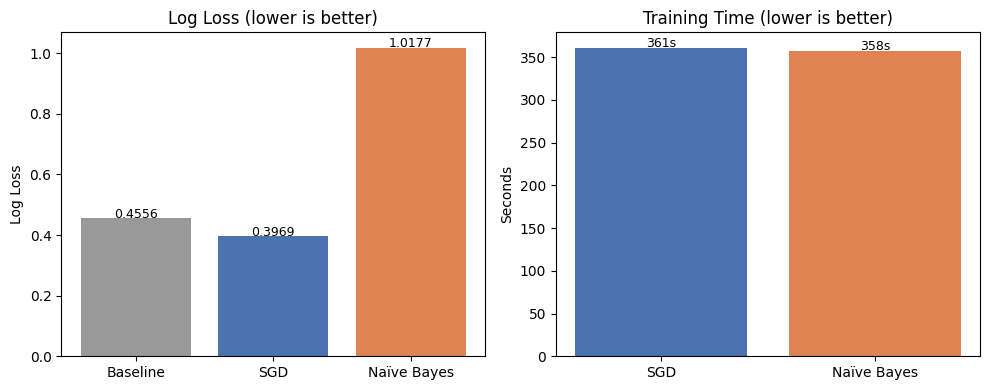

In [22]:
# ── Summary table ─────────────────────────────────────────────────────────────

results = pd.DataFrame({
    "Model": ["Baseline (avg CTR)", "SGD Logistic Regression", "Naïve Bayes"],
    "Log Loss": [baseline_log_loss, sgd_log_loss, nb_log_loss],
    "Training Time (s)": ["-", f"{sgd_elapsed:.1f}", f"{nb_elapsed:.1f}"],
})
print(results.to_string(index=False))

# ── Bar chart comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Log loss comparison
models = ["Baseline", "SGD", "Naïve Bayes"]
losses = [baseline_log_loss, sgd_log_loss, nb_log_loss]
colors = ["#999999", "#4c72b0", "#dd8452"]
axes[0].bar(models, losses, color=colors)
axes[0].set_title("Log Loss (lower is better)")
axes[0].set_ylabel("Log Loss")
for i, v in enumerate(losses):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

# Training time comparison
axes[1].bar(["SGD", "Naïve Bayes"], [sgd_elapsed, nb_elapsed], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Training Time (lower is better)")
axes[1].set_ylabel("Seconds")
for i, v in enumerate([sgd_elapsed, nb_elapsed]):
    axes[1].text(i, v + 1, f"{v:.0f}s", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

---

## Discussion Prompts (for the report)

**1. Insights from exploring the dataset**
- How imbalanced is the target? What does this mean for modelling?
- Which features have very high cardinality? Why is that a problem?
- Are there time-of-day patterns in CTR?

**2. How you selected which variables to include**
- Why did we drop `id`, `device_ip`, `device_id`?
- Why did we extract `hour_of_day` from the raw `hour` column?
- What would happen if we included all columns?

**3. How you chose the parameters of your models**
- SGD: Why `alpha=1e-4`? Why `learning_rate='optimal'`? Why L2 regularisation?
- NB: Why `alpha=1.0`? What does Laplace smoothing do?
- What would you change and why?

**4. How you evaluated the models on unseen data**
- Why a temporal split instead of random?
- How does incremental log loss work? Why is it memory-efficient?
- Why log loss instead of accuracy?

**5. How the calculation times of the two models compare**
- Which model was faster? Why? (Counting vs. gradient computation)
- How does chunk size affect training time?

**6. Practical difficulties encountered**
- Memory constraints with 40M rows
- Feature encoding for high-cardinality categoricals
- Hash collisions — do they matter?
- Ensuring `alternate_sign=False` for MultinomialNB

**7. Which model would you advise to implement?**
- Compare log loss (prediction quality) vs. training time (operational cost)
- Consider: which model produces better-calibrated probabilities?
- Consider: which model is easier to maintain and retrain in production?